In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")


Libraries imported successfully!


In [2]:
df = pd.read_csv("per-capita-plastic-waste-vs-gdp-per-capita.csv")

df.head()

,Entity,Code,Year,Per capita plastic waste (kg/person/day),"GDP per capita, PPP (constant 2011 international $)","Total population (Gapminder, HYDE & UN)",Continent
0,Abkhazia,OWID_ABK,2015,NaN,NaN,NaN,Asia
1,Afghanistan,AFG,2002,NaN,1063.635574,22601000.0,NaN
2,Afghanistan,AFG,2003,NaN,1099.194507,23681000.0,NaN
3,Afghanistan,AFG,2004,NaN,1062.249360,24727000.0,NaN
4,Afghanistan,AFG,2005,NaN,1136.123214,25654000.0,NaN


# Global Plastic Pollution Analysis

## 1. Introduction

Plastic pollution is one of the major environmental challenges in the world.
This project analyzes global plastic waste generation across different
countries and years.

The analysis focuses on per-capita plastic waste and investigates whether
there is a relationship between plastic waste generation and GDP per capita.

The project uses Python and data science techniques such as data cleaning,
exploratory data analysis, data visualization, correlation analysis, and
machine learning.

In [5]:
df.head()

,Entity,Code,Year,Per capita plastic waste (kg/person/day),"GDP per capita, PPP (constant 2011 international $)","Total population (Gapminder, HYDE & UN)",Continent
0,Abkhazia,OWID_ABK,2015,NaN,NaN,NaN,Asia
1,Afghanistan,AFG,2002,NaN,1063.635574,22601000.0,NaN
2,Afghanistan,AFG,2003,NaN,1099.194507,23681000.0,NaN
3,Afghanistan,AFG,2004,NaN,1062.249360,24727000.0,NaN
4,Afghanistan,AFG,2005,NaN,1136.123214,25654000.0,NaN


## 2. Objectives

The main objectives of this project are:

1. Analyze global plastic waste generation.
2. Identify countries with high and low per-capita plastic waste.
3. Study changes in plastic waste over time.
4. Analyze the relationship between GDP per capita and plastic waste.
5. Visualize the data using graphs and charts.
6. Build a simple machine learning model to study the relationship between
   GDP per capita and plastic waste.
7. Draw meaningful conclusions from the analysis.

## 3. Dataset Information

The dataset contains information about per-capita plastic waste,
GDP per capita, total population, country/entity, year, and continent.

The dataset is used to study the relationship between plastic waste
generation and economic development across different countries.

In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 48168
Number of columns: 7


In [7]:
print("Column Names:")
for column in df.columns:
    print(column)

Column Names:
Entity
Code
Year
Per capita plastic waste (kg/person/day)
GDP per capita, PPP (constant 2011 international $)
Total population (Gapminder, HYDE & UN)
Continent


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48168 entries, 0 to 48167
Data columns (total 7 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Entity                                               48168 non-null  str    
 1   Code                                                 46154 non-null  str    
 2   Year                                                 48168 non-null  int64  
 3   Per capita plastic waste (kg/person/day)             186 non-null    float64
 4   GDP per capita, PPP (constant 2011 international $)  6407 non-null   float64
 5   Total population (Gapminder, HYDE & UN)              46883 non-null  float64
 6   Continent                                            285 non-null    str    
dtypes: float64(3), int64(1), str(3)
memory usage: 2.6 MB


In [9]:
df.isnull().sum()

Entity                                                     0
Code                                                    2014
Year                                                       0
Per capita plastic waste (kg/person/day)               47982
GDP per capita, PPP (constant 2011 international $)    41761
Total population (Gapminder, HYDE & UN)                 1285
Continent                                              47883
dtype: int64

In [10]:
df.describe()

,Year,Per capita plastic waste (kg/person/day),"GDP per capita, PPP (constant 2011 international $)","Total population (Gapminder, HYDE & UN)"
count,48168.000000,186.000000,6407.000000,4.688300e+04
mean,1903.147442,0.179812,14926.095591,2.982790e+07
std,315.716839,0.123006,17739.754531,2.530860e+08
min,-10000.000000,0.010000,247.436540,9.050000e+02
25%,1859.000000,0.103000,3021.071807,2.017335e+05
50%,1920.000000,0.144000,8447.264179,1.542937e+06
75%,1975.000000,0.252000,19607.537075,5.886795e+06
max,2019.000000,0.686000,135318.754421,7.713468e+09


## 4. Data Cleaning

Data cleaning is performed to identify missing values, duplicate records,
and unnecessary records. The dataset is then prepared for exploratory
analysis and machine learning.


In [11]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Entity                                                     0
Code                                                    2014
Year                                                       0
Per capita plastic waste (kg/person/day)               47982
GDP per capita, PPP (constant 2011 international $)    41761
Total population (Gapminder, HYDE & UN)                 1285
Continent                                              47883
dtype: int64


In [12]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [13]:
plastic_df = df.dropna(
    subset=["Per capita plastic waste (kg/person/day)"]
).copy()

print("Rows containing plastic waste data:", len(plastic_df))

Rows containing plastic waste data: 186


In [14]:
print("Years available for plastic waste data:")
print(plastic_df["Year"].unique())

Years available for plastic waste data:
[2010]


In [15]:
print(
    "Missing GDP values:",
    plastic_df["GDP per capita, PPP (constant 2011 international $)"].isnull().sum()
)

Missing GDP values: 38


In [16]:
analysis_df = plastic_df.dropna(
    subset=[
        "Per capita plastic waste (kg/person/day)",
        "GDP per capita, PPP (constant 2011 international $)"
    ]
).copy()

print("Rows available for GDP analysis:", len(analysis_df))

Rows available for GDP analysis: 148


## 5. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the distribution
of plastic waste, identify countries with high and low plastic waste
generation, and examine the relationship between plastic waste and
economic development.

In [17]:
plastic_column = "Per capita plastic waste (kg/person/day)"

print("Mean:", plastic_df[plastic_column].mean())
print("Median:", plastic_df[plastic_column].median())
print("Minimum:", plastic_df[plastic_column].min())
print("Maximum:", plastic_df[plastic_column].max())

Mean: 0.17981182795698925
Median: 0.144
Minimum: 0.01
Maximum: 0.686


### Top 10 Countries by Per-Capita Plastic Waste

In [18]:
top_10 = plastic_df.sort_values(
    by=plastic_column,
    ascending=False
).head(10)

top_10[["Entity", plastic_column]]

,Entity,Per capita plastic waste (kg/person/day)
22097,Kuwait,0.686
1365,Antigua and Barbuda,0.660
35811,Saint Kitts and Nevis,0.654
17628,Guyana,0.586
3567,Barbados,0.570
36031,Saint Lucia,0.522
15806,Germany,0.485
20028,Ireland,0.430
29878,Netherlands,0.424
18348,Hong Kong,0.398


In [19]:
bottom_10 = plastic_df.sort_values(
    by=plastic_column,
    ascending=True
).head(10)

bottom_10[["Entity", plastic_column]]

,Entity,Per capita plastic waste (kg/person/day)
19148,India,0.010
28777,Mozambique,0.015
24933,Madagascar,0.016
42346,Tanzania,0.023
5980,Brunei,0.026
21639,Kenya,0.027
17188,Guinea,0.030
20758,Jamaica,0.034
3347,Bangladesh,0.034
16026,Ghana,0.040


## 6. Data Visualization

Data visualization is used to represent the findings using charts and
graphs. Visualizations make it easier to compare countries and understand
patterns in plastic waste generation.

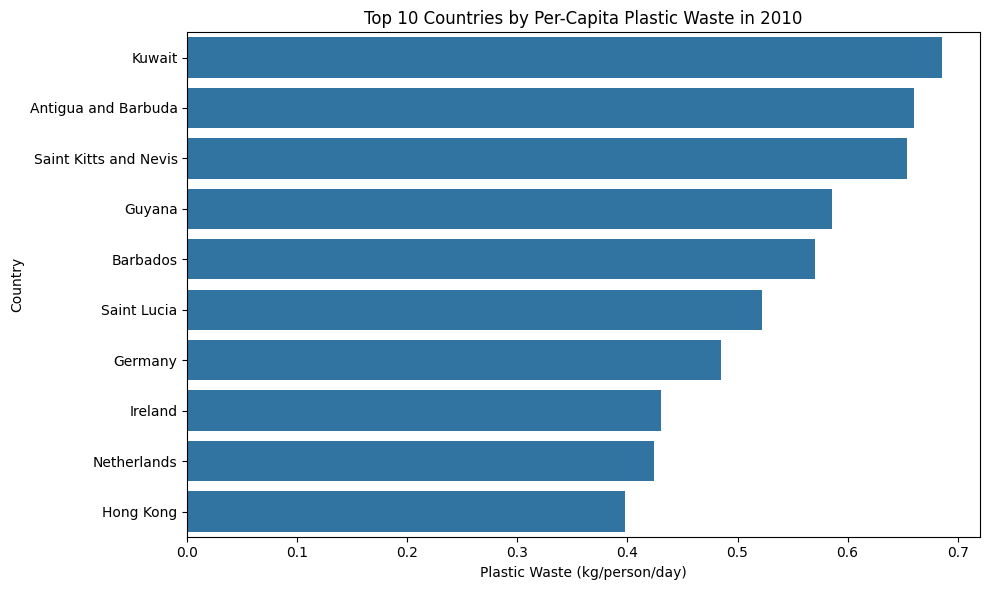

In [20]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_10,
    x=plastic_column,
    y="Entity"
)

plt.title("Top 10 Countries by Per-Capita Plastic Waste in 2010")
plt.xlabel("Plastic Waste (kg/person/day)")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

### Distribution of Per-Capita Plastic Waste

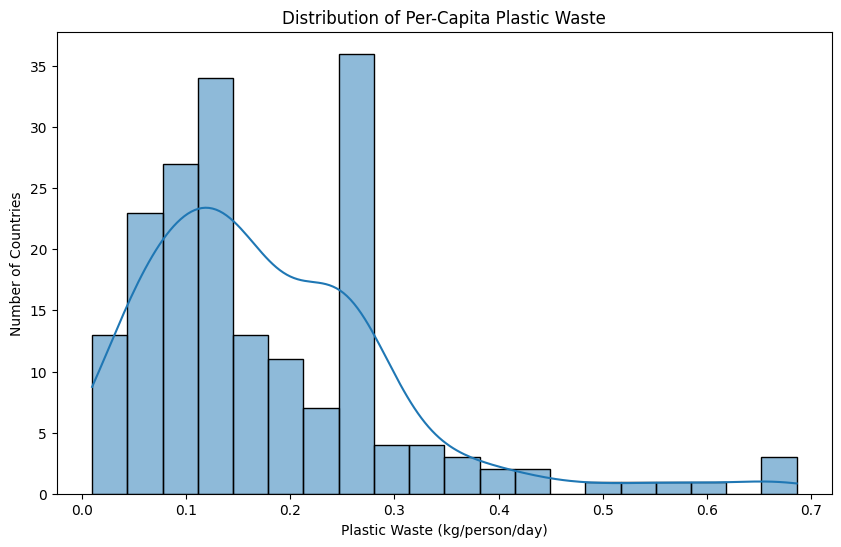

In [21]:
plt.figure(figsize=(10, 6))

sns.histplot(
    plastic_df[plastic_column],
    bins=20,
    kde=True
)

plt.title("Distribution of Per-Capita Plastic Waste")
plt.xlabel("Plastic Waste (kg/person/day)")
plt.ylabel("Number of Countries")

plt.show()

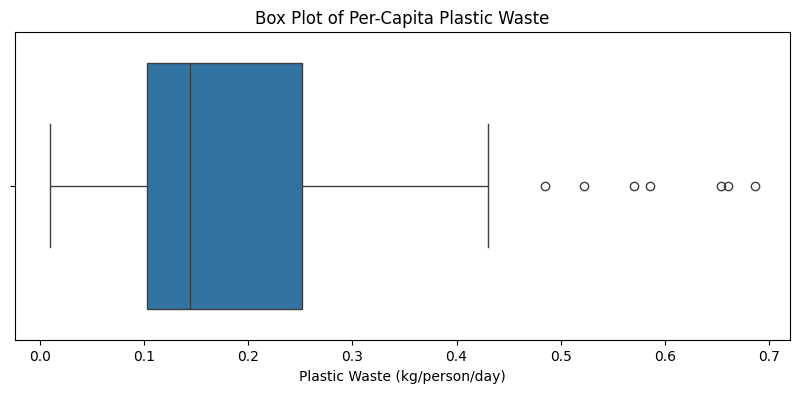

In [22]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=plastic_df[plastic_column]
)

plt.title("Box Plot of Per-Capita Plastic Waste")
plt.xlabel("Plastic Waste (kg/person/day)")

plt.show()

In [23]:
india = plastic_df[
    plastic_df["Entity"] == "India"
]

india[[
    "Entity",
    "Year",
    plastic_column,
    "GDP per capita, PPP (constant 2011 international $)",
    "Total population (Gapminder, HYDE & UN)"
]]

,Entity,Year,Per capita plastic waste (kg/person/day),"GDP per capita, PPP (constant 2011 international $)","Total population (Gapminder, HYDE & UN)"
19148,India,2010,0.01,4404.697005,1.234281e+09


In [24]:
selected_countries = [
    "India",
    "China",
    "United States",
    "Germany",
    "Brazil",
    "United Kingdom"
]

comparison = plastic_df[
    plastic_df["Entity"].isin(selected_countries)
]

comparison[["Entity", plastic_column]]

,Entity,Per capita plastic waste (kg/person/day)
5689,Brazil,0.165
8596,China,0.121
15806,Germany,0.485
19148,India,0.010
45350,United Kingdom,0.215
45571,United States,0.335


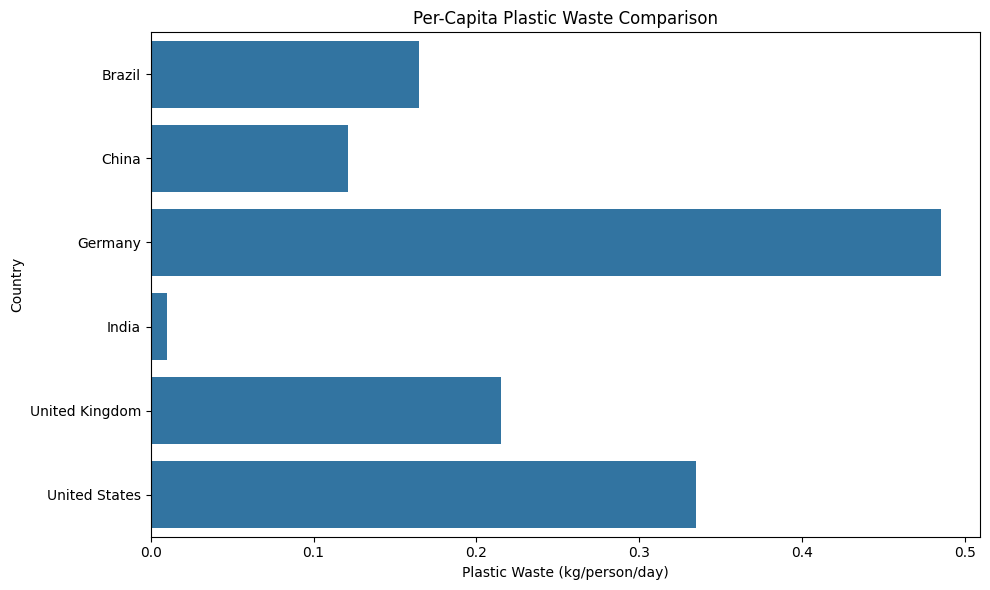

In [25]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=comparison,
    x=plastic_column,
    y="Entity"
)

plt.title("Per-Capita Plastic Waste Comparison")
plt.xlabel("Plastic Waste (kg/person/day)")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

## 7. Correlation Analysis

Correlation analysis is used to measure the strength and direction of
the relationship between GDP per capita and per-capita plastic waste.

A positive correlation indicates that higher GDP values tend to be
associated with higher plastic waste values, while a negative correlation
indicates an inverse relationship.

In [26]:
gdp_column = "GDP per capita, PPP (constant 2011 international $)"

correlation_df = analysis_df[
    [plastic_column, gdp_column]
].copy()

correlation_df.head()

,Per capita plastic waste (kg/person/day),"GDP per capita, PPP (constant 2011 international $)"
344,0.069,9927.181841
564,0.144,12870.602699
1074,0.062,5897.682841
1365,0.660,19212.720131
1613,0.183,18712.063077


In [27]:
correlation = correlation_df.corr()

print(correlation)

                                                    Per capita plastic waste (kg/person/day)  \
Per capita plastic waste (kg/person/day)                                            1.000000   
GDP per capita, PPP (constant 2011 internationa...                                  0.346595   

                                                    GDP per capita, PPP (constant 2011 international $)  
Per capita plastic waste (kg/person/day)                                                     0.346595    
GDP per capita, PPP (constant 2011 internationa...                                           1.000000    


In [28]:
corr_value = correlation_df[plastic_column].corr(
    correlation_df[gdp_column]
)

print("Correlation coefficient:", corr_value)

Correlation coefficient: 0.34659468909221025


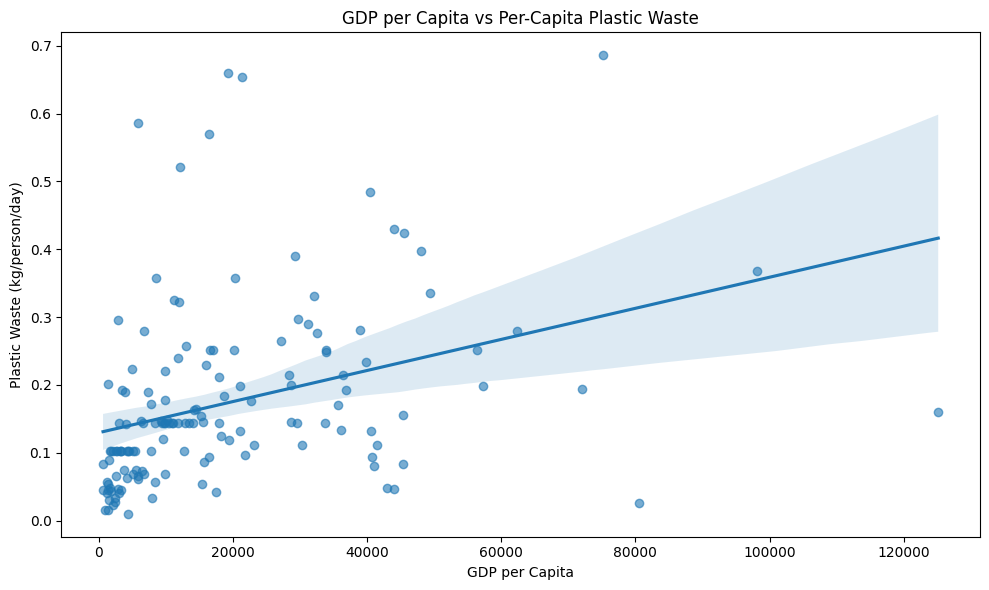

In [29]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=analysis_df,
    x=gdp_column,
    y=plastic_column,
    scatter_kws={"alpha": 0.6}
)

plt.title("GDP per Capita vs Per-Capita Plastic Waste")
plt.xlabel("GDP per Capita")
plt.ylabel("Plastic Waste (kg/person/day)")

plt.tight_layout()
plt.show()

## 8. Machine Learning

A Linear Regression model is used to investigate whether GDP per capita
can be used as a predictor of per-capita plastic waste.

GDP per capita is used as the independent variable, while per-capita
plastic waste is used as the dependent variable.

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [32]:
X = analysis_df[[gdp_column]]

y = analysis_df[plastic_column]

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 118
Testing records: 30


In [34]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [35]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[0.19746998 0.14723354 0.14959347 0.13919114 0.1541246  0.1368299
 0.17774465 0.13436767 0.19324648 0.16785662]


In [36]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)

Mean Absolute Error: 0.081323384921283
Mean Squared Error: 0.011392408364274487
Root Mean Squared Error: 0.10673522550814463
R² Score: 0.14479833711351586


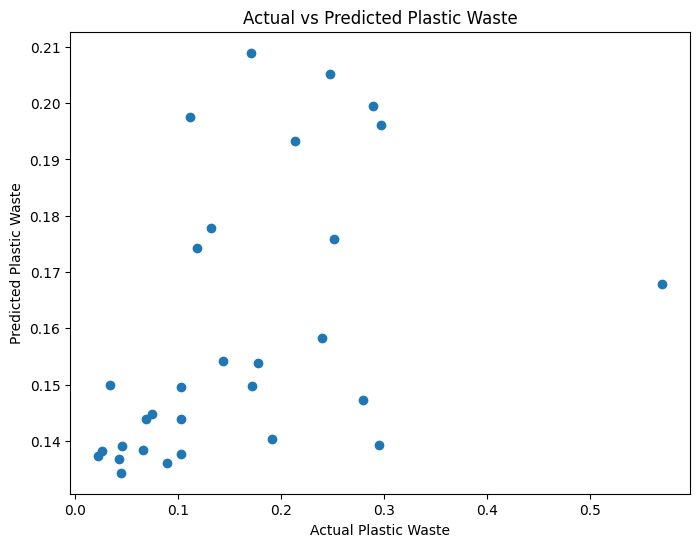

In [37]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Plastic Waste")
plt.ylabel("Predicted Plastic Waste")
plt.title("Actual vs Predicted Plastic Waste")

plt.show()

In [38]:
print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

Coefficient: 2.1252370279246167e-06
Intercept: 0.13296456095685374


In [39]:
continent_analysis = plastic_df.groupby(
    "Continent"
)[plastic_column].mean().sort_values(ascending=False)

print(continent_analysis)

Series([], Name: Per capita plastic waste (kg/person/day), dtype: float64)


### Machine Learning Results

A Linear Regression model was developed using GDP per capita as the
independent variable and per-capita plastic waste as the dependent
variable.

The dataset was divided into 118 training records and 30 testing records.

The model achieved a Mean Absolute Error (MAE) of 0.0813, a Mean Squared
Error (MSE) of 0.01139, and a Root Mean Squared Error (RMSE) of 0.1067.

The R² score was 0.1448, meaning that the model explains approximately
14.48% of the variation in per-capita plastic waste.

The positive regression coefficient indicates that plastic waste tends
to increase as GDP per capita increases. However, the relatively low R²
score indicates that GDP per capita alone is not sufficient to accurately
predict plastic waste generation. Other factors such as consumption
patterns, urbanization, population characteristics, recycling systems,
waste-management infrastructure, and environmental policies may also
influence plastic waste.

## 9. Results and Findings

The analysis produced several important findings from the global plastic
pollution dataset.

### 1. Plastic Waste

The dataset contains per-capita plastic waste observations for 186
countries or entities for the year 2010. The average per-capita plastic
waste is approximately 0.180 kg/person/day, while the median is
approximately 0.144 kg/person/day.

The observed values range from approximately 0.010 kg/person/day to
0.686 kg/person/day.

### 2. GDP and Plastic Waste Relationship

The Pearson correlation coefficient between GDP per capita and
per-capita plastic waste is 0.3466.

This indicates a weak-to-moderate positive linear relationship. Countries
with higher GDP per capita tend to have somewhat higher per-capita
plastic waste, although the relationship is not strong.

### 3. Machine Learning

A Linear Regression model was trained using GDP per capita to predict
per-capita plastic waste.

The model used 118 training records and 30 testing records.

The model achieved:

- MAE: 0.0813
- MSE: 0.01139
- RMSE: 0.1067
- R² Score: 0.1448

The R² score indicates that approximately 14.48% of the variation in
plastic waste is explained by GDP per capita in this model.

### 4. Overall Finding

The analysis shows that GDP per capita has a positive association with
plastic waste, but GDP alone is not a strong predictor of plastic waste
generation.

This suggests that environmental, demographic, economic, and
waste-management factors should be considered for a more accurate
prediction model.

## 10. Conclusion

This project analyzed global per-capita plastic waste using data science
techniques. The analysis focused on data from 2010 because the available
plastic-waste measurements in the dataset are for that year.

Exploratory data analysis was used to identify countries with high and
low levels of per-capita plastic waste. Different visualization techniques
were used to understand the distribution of plastic waste and compare
countries.

Correlation analysis was performed to investigate the relationship between
GDP per capita and plastic waste. A Linear Regression model was also
developed to examine whether GDP per capita could be used to predict
per-capita plastic waste.

The project demonstrates how data science can be used to analyze
environmental data and generate meaningful insights that can support
awareness and sustainable waste-management decisions.

## 11. Future Scope

The project can be extended in several ways:

1. Use newer plastic-waste datasets containing multiple years.
2. Analyze changes in plastic waste over time.
3. Include additional factors such as urbanization, population density,
   recycling rate, waste-management infrastructure, and consumption.
4. Apply advanced machine learning models such as Random Forest and
   Gradient Boosting.
5. Develop an interactive dashboard using Streamlit or Power BI.
6. Perform geographical analysis using maps.
7. Compare plastic waste across different continents and income groups.
8. Use more recent environmental data to improve the analysis.

# Project Summary

This project demonstrated the complete data science workflow:

Dataset → Data Cleaning → Exploratory Data Analysis →
Visualization → Correlation Analysis → Machine Learning →
Results → Conclusion